In [1]:
import pandas as pd


## Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/iPriyadarshi/MachineLearning-BCS4706/main/dataset/salary_data.csv"
df = pd.read_csv(url)


In [3]:
# display first 5 rows
df.head()


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## Exploratory Data Analysis

In [4]:
df.shape


(30, 2)

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [6]:
# Statistical Summary
df.describe()


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


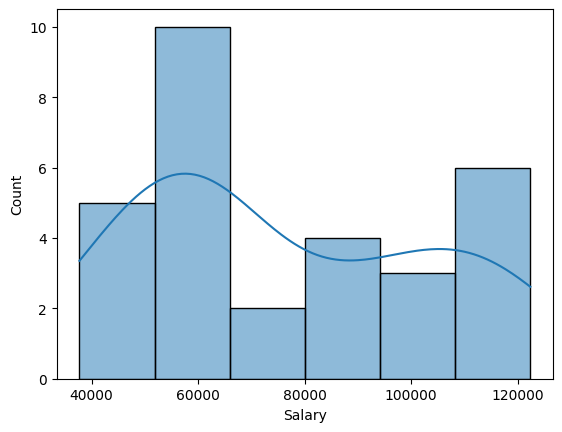

In [8]:
sns.histplot(df["Salary"], kde=True)
plt.show()


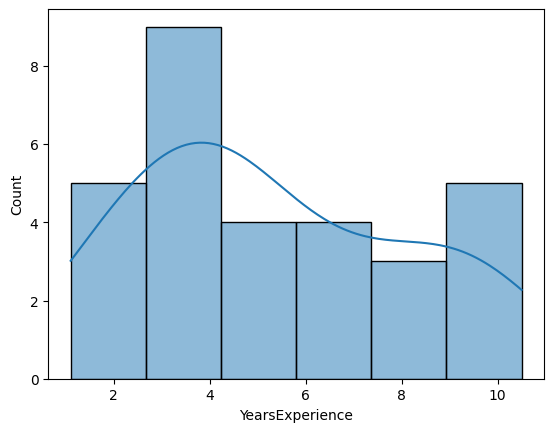

In [9]:
sns.histplot(df["YearsExperience"], kde=True)
plt.show()


In [10]:
# Check null values
df.isnull().sum()


YearsExperience    0
Salary             0
dtype: int64

## Feature and target selection

In [11]:
X = df[['YearsExperience']] # input features
y = df['Salary']    # target output


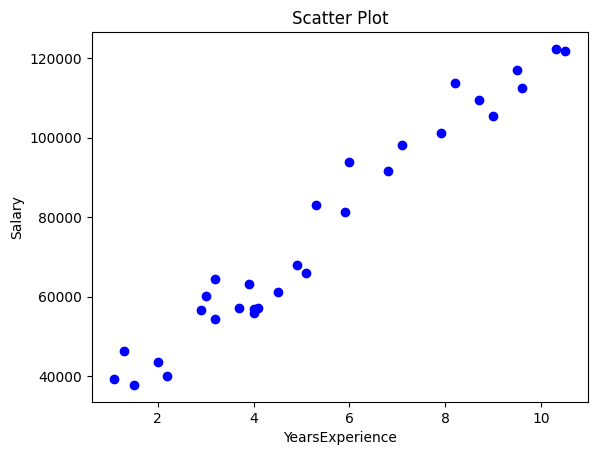

In [12]:
plt.scatter(X, y, color='blue')
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Scatter Plot")
plt.show()


## Train Test Split

In [13]:
from sklearn.model_selection import train_test_split


In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


## Train Linear Regression model

In [15]:
from sklearn.linear_model import LinearRegression

model  = LinearRegression()


In [16]:
model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
# parameters
print("Slope: " , model.coef_[0])
print("Intercept: " , model.intercept_)


Slope:  9423.815323030976
Intercept:  25321.583011776813


## Predictions

In [18]:
y_pred = model.predict(X_test)


## Evaluation

In [19]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error,r2_score


In [20]:
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("Mean Square Error: " , mse)
print("Root Mean Square Error: " , rmse)
print("R2 Score: " , r2)


Mean Square Error:  49830096.85590839
Root Mean Square Error:  7059.04362190151
R2 Score:  0.9024461774180497


## Visualization (Regression Line)

### Training Data Visualization

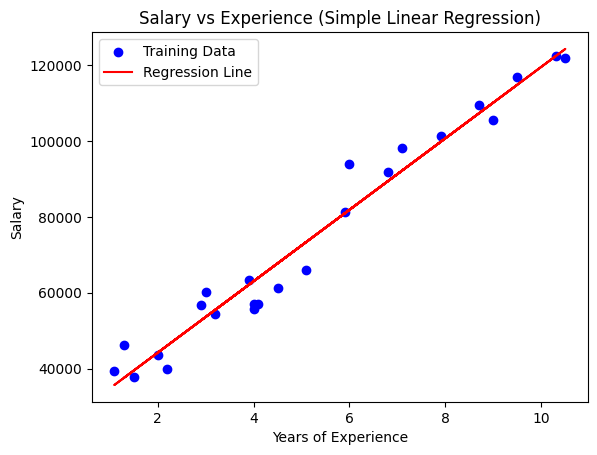

In [21]:
# Plot regression line
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.plot(X_train, model.predict(X_train), color='red', label='Regression Line')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience (Simple Linear Regression)")
plt.legend()
plt.show()


### Test Data Visualization

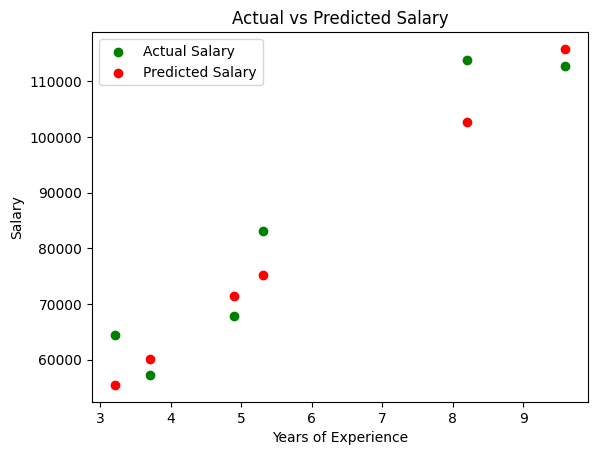

In [22]:
# Test data comparison
plt.scatter(X_test, y_test, color='green', label='Actual Salary')
plt.scatter(X_test, y_pred, color='red', label='Predicted Salary')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.show()
